# Morbidity Pattern Analysis — IMSS & INEGI
**Academic consulting project | Tecnológico de Monterrey × BBVA · 2024**

---

This notebook analyzes morbidity trends across Mexico using two public health datasets:

| Dataset | Source | Coverage |
|---|---|---|
| `new.csv` | IMSS | Patient counts by disease, state & year (1995–2020) |
| `total pacientes.csv` | INEGI | National morbidity across 21 disease categories (2004–2023) |

**Workflow:**
1. [Part 1 — IMSS](#part1): Load & explore · Top diseases · Regional trends · State-level clustering  
2. [Part 2 — INEGI](#part2): Load & clean · Trend visualization · Predictive modeling (2030) · Disease clustering

**Key finding:** Predictive models project a **25% increase in total patient demand by 2030**, driven mainly by digestive, respiratory, and pregnancy-related conditions.


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import mean_squared_error
from scipy.cluster.hierarchy import dendrogram, linkage

from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/Proyectos_uni/IMSS/'

# ── helper: format large numbers on y-axis ──
def fmt_y(x, _):
    return f'{int(x):,}'


Mounted at /content/drive


---
<a id='part1'></a>
## Part 1 — IMSS Dataset (`new.csv`)

The IMSS dataset contains patient counts broken down by **disease, state, and year** (1995–2020).  
Each row is one (disease, state, year) combination with a patient count in `value`.

We explore:
- Trends in vaccine-preventable diseases nationally
- Regional patterns for select vector-borne / rare diseases
- Most prevalent conditions in 2020
- State-level clustering by total patient volume


In [ ]:
imss = pd.read_csv(DATA_PATH + 'new.csv')
imss['date'] = pd.to_datetime(imss['date'])

diseases  = np.unique(imss['sickness'])
states    = np.unique(imss['state'])
years     = np.unique(imss['year'])

print(f"Records : {len(imss):,}")
print(f"Diseases: {len(diseases)}")
print(f"States  : {len(states)}")
print(f"Years   : {years.min()} – {years.max()}")
imss.head()


Records : 1,026,480
Diseases: 127
States  : 35
Years   : 1995 – 2020


,date,sickness,state,value,year
0,1995-01-15,accidentes laborales,aguascalientes,36.0,1995
1,1995-01-15,accidentes laborales,baja california,26.0,1995
2,1995-01-15,accidentes laborales,baja california sur,62.0,1995
3,1995-01-15,accidentes laborales,campeche,214.0,1995
4,1995-01-15,accidentes laborales,chiapas,225.0,1995


### 1.1 Vaccine-Preventable Diseases — National Trends

Tracking polio, measles, rubella, tetanus, influenza, and diphtheria over time reveals the impact of vaccination programs and coverage gaps.


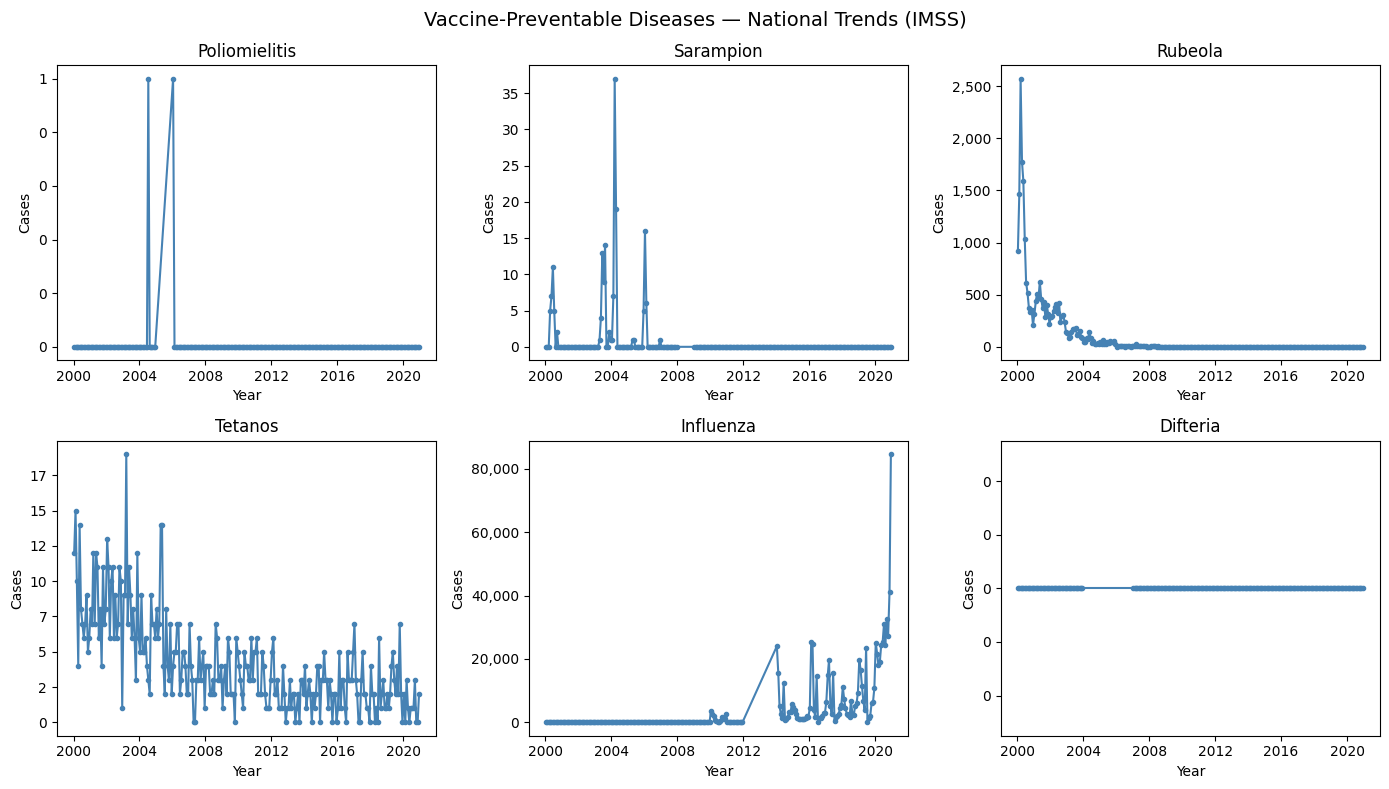

In [ ]:
vaccine_diseases = ['poliomielitis', 'sarampion', 'rubeola', 'tetanos', 'influenza', 'difteria']
nat = imss[imss['state'] == 'total global']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Vaccine-Preventable Diseases — National Trends (IMSS)', fontsize=14)

for ax, disease in zip(axes.flat, vaccine_diseases):
    d = nat[nat['sickness'] == disease]
    ax.plot(d['date'], d['value'], marker='.', color='steelblue')
    ax.set_title(disease.capitalize())
    ax.set_xlabel('Year')
    ax.set_ylabel('Cases')
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_y))

plt.tight_layout()
plt.show()


**Findings:**

- **Poliomyelitis, measles, rubella, and diphtheria** showed near-zero or zero cases throughout the entire period — a clear indicator of the success of Mexico's national vaccination programs.
- **Influenza** displayed notable fluctuations with an overall upward trend in recent years, likely reflecting a combination of improved surveillance systems and specific outbreak events.
- **Tetanus** remained consistently low and stable, suggesting sustained vaccination coverage in the general population.

> These trends highlight that vaccine-preventable diseases are well-controlled nationally, though influenza continues to require active monitoring.


### 1.2 Region-Specific Diseases by State

Dengue hemorrhagic fever, leprosy, and pinto fever show strong geographic concentration. Here we compare five states with historically high caseloads.


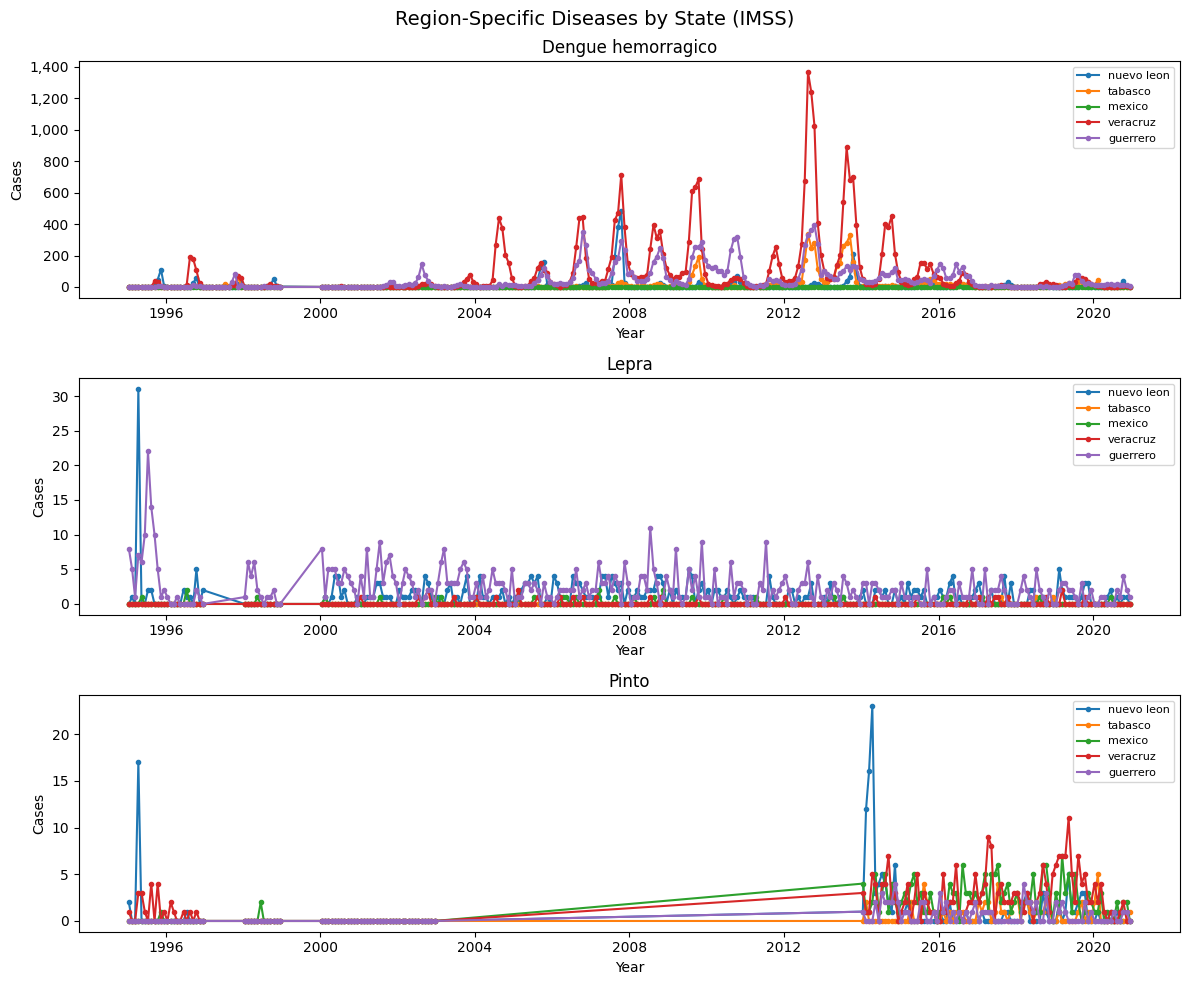

In [ ]:
regional_diseases = ['dengue hemorragico', 'lepra', 'pinto']
focus_states      = ['nuevo leon', 'tabasco', 'mexico', 'veracruz', 'guerrero']

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle('Region-Specific Diseases by State (IMSS)', fontsize=14)

for ax, disease in zip(axes, regional_diseases):
    for state in focus_states:
        d = imss[(imss['sickness'] == disease) & (imss['state'] == state)]
        ax.plot(d['date'], d['value'], marker='.', label=state)
    ax.set_title(disease.capitalize())
    ax.set_xlabel('Year')
    ax.set_ylabel('Cases')
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_y))

plt.tight_layout()
plt.show()


**Findings:**

- **Dengue hemorrhagic fever**: Tabasco and Guerrero showed the highest historical caseloads, with Tabasco recording the most pronounced spikes — consistent with its tropical climate and proximity to endemic zones.
- **Leprosy**: Cases were concentrated in Nuevo León, Estado de México, and Guerrero, with a notable peak in Nuevo León that warrants further epidemiological investigation.
- **Pinto fever**: Guerrero reported the majority of cases, though in relatively low volumes compared to the other two diseases.

> The geographic concentration of these diseases underscores the need for region-specific public health interventions rather than uniform national policies.


### 1.3 Most Prevalent Conditions — 2020

Bar chart and pie chart of the top 5 diseases (plus "Other") by total national cases in 2020.


/tmp/ipykernel_1723/777719583.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, rotation=30, ha='right')


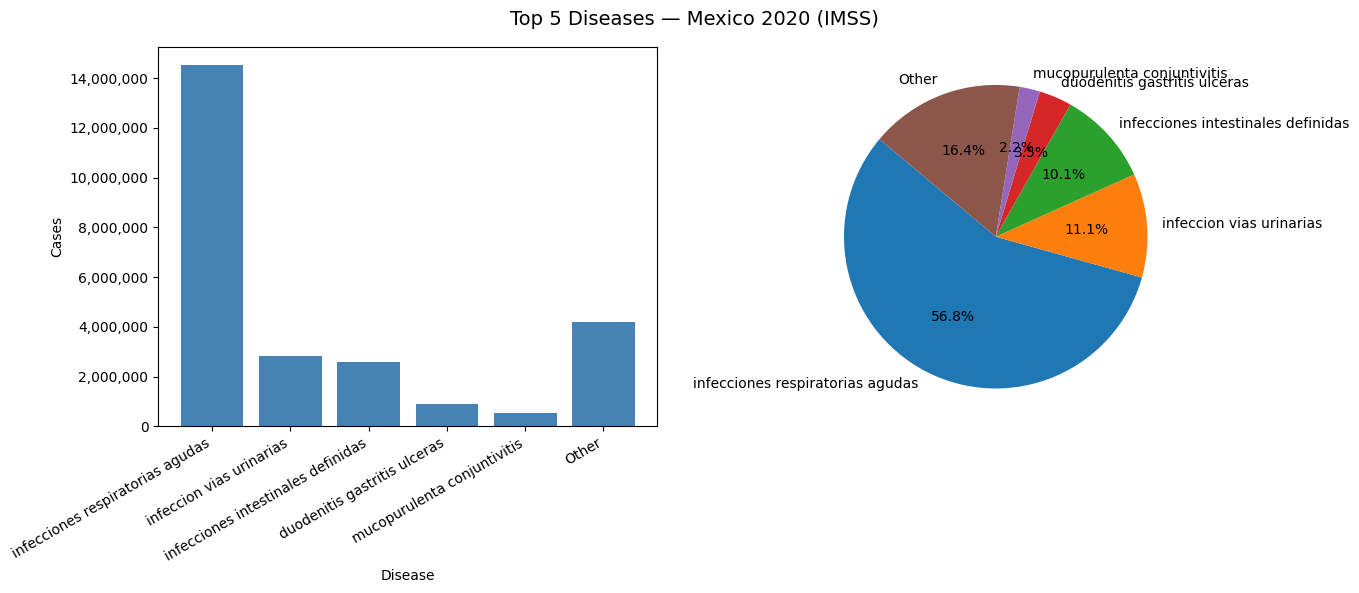

In [ ]:
year_filter = 2020
nat_year = imss[(imss['state'] == 'total global') & (imss['year'] == year_filter)]

# Total cases per disease
totals = (
    nat_year.groupby('sickness')['value'].sum()
    .sort_values(ascending=False)
)

Nmax   = 5
top    = totals.iloc[:Nmax]
other  = totals.iloc[Nmax:].sum()
labels = list(top.index) + ['Other']
counts = list(top.values)  + [other]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Top {Nmax} Diseases — Mexico {year_filter} (IMSS)', fontsize=14)

ax1.bar(labels, counts, color='steelblue')
ax1.set_xlabel('Disease')
ax1.set_ylabel('Cases')
ax1.set_xticklabels(labels, rotation=30, ha='right')
ax1.yaxis.set_major_formatter(FuncFormatter(fmt_y))

ax2.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140)

plt.tight_layout()
plt.show()


**Findings — Most Prevalent Conditions in 2020 (IMSS):**

- **Acute respiratory infections** were by far the dominant condition, with over **14.5 million cases** — representing the largest single burden on IMSS capacity.
- **Urinary tract infections** ranked second (~2.8M cases), followed by **defined intestinal infections** (~2.5M cases).
- These three conditions alone account for the vast majority of patient volume, suggesting that targeted investments in primary care for respiratory and gastrointestinal conditions could have an outsized impact on system-wide demand.


### 1.4 State-Level Clustering — K-Means (k=6)

We aggregate total IMSS patient counts per state (excluding the "total global" summary row) and apply K-Means to group states by healthcare burden. This can guide where to prioritize infrastructure investment.


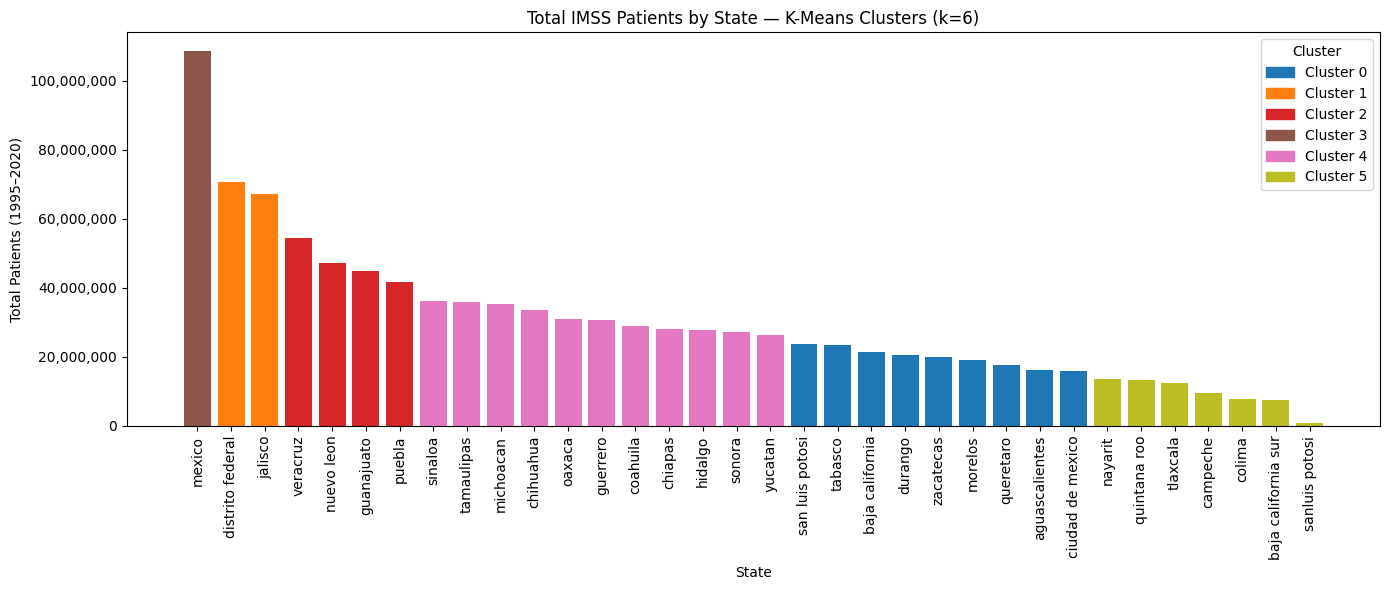

              state       total  Cluster
             mexico 108621350.0        3
   distrito federal  70766450.0        1
            jalisco  67313438.0        1
           veracruz  54374537.0        2
         nuevo leon  47291889.0        2
         guanajuato  44983461.0        2
             puebla  41805892.0        2
            sinaloa  36120844.0        4
         tamaulipas  35842728.0        4
          michoacan  35455848.0        4
          chihuahua  33614761.0        4
             oaxaca  31078151.0        4
           guerrero  30586253.0        4
           coahuila  28839223.0        4
            chiapas  28159696.0        4
            hidalgo  27874933.0        4
             sonora  27216883.0        4
            yucatan  26264884.0        4
    san luis potosi  23799977.0        0
            tabasco  23591629.0        0
    baja california  21334420.0        0
            durango  20476351.0        0
          zacatecas  19862313.0        0
            more

In [ ]:
state_totals = (
    imss[imss['state'].str.lower() != 'total global']
    .groupby('state')['value'].sum()
    .reset_index()
    .rename(columns={'value': 'total'})
)

scaler = StandardScaler()
state_totals['scaled'] = scaler.fit_transform(state_totals[['total']])

kmeans_state = KMeans(n_clusters=6, random_state=42, n_init=10)
state_totals['Cluster'] = kmeans_state.fit_predict(state_totals[['scaled']])
state_totals = state_totals.sort_values('total', ascending=False)

colors = plt.cm.tab10(state_totals['Cluster'].values / 6)

plt.figure(figsize=(14, 6))
plt.bar(state_totals['state'], state_totals['total'], color=colors)
plt.title('Total IMSS Patients by State — K-Means Clusters (k=6)')
plt.xlabel('State')
plt.ylabel('Total Patients (1995–2020)')
plt.xticks(rotation=90)
plt.gca().yaxis.set_major_formatter(FuncFormatter(fmt_y))

# Legend
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=plt.cm.tab10(i/6), label=f'Cluster {i}') for i in range(6)]
plt.legend(handles=handles, title='Cluster')
plt.tight_layout()
plt.show()

print(state_totals[['state', 'total', 'Cluster']].to_string(index=False))


---
<a id='part2'></a>
## Part 2 — INEGI Dataset (`total pacientes.csv`)

The INEGI dataset tracks national morbidity across **21 disease categories** from 2004 to 2023.  
Each column is a disease category; each row is a year.

We:
1. Clean and load the data
2. Visualize trends per category
3. Build predictive models to forecast demand through 2030
4. Cluster disease categories by patient volume trajectory


### 2.1 Data Loading & Cleaning

In [ ]:
inegi = pd.read_csv(DATA_PATH + 'total pacientes.csv', encoding='latin1', engine='python')
inegi.columns = inegi.columns.str.strip()
inegi.replace(r'^\s*$', 0, regex=True, inplace=True)
inegi.fillna(0, inplace=True)
inegi['Año'] = pd.to_numeric(inegi['Año'], errors='coerce')

categories = [col for col in inegi.columns if col not in ['Año', 'Total']]

print(f"Years    : {int(inegi['Año'].min())} – {int(inegi['Año'].max())}")
print(f"Categories: {len(categories)}")
inegi.head()


Years    : 2004 – 2023
Categories: 21


,Año,Total,Ciertas enfermedades infecciosas y parasitarias,Tumores [NEOPLASIAS],"Enfermedades de la sangre y de los organos hematopoyéticos, y ciertos transtornos que afectan el mecanismo de la inmunidad","Enfermedades endócrinas, nutricionales y metabólicas",Transtornos mentales y del comportamiento,Enfermedades del sistema nervioso,Enfermedades del ojo y sus anexos,Enfermedades del oído y de las apófisis mastóides,...,Enfermedades de la piel y del tejido subcutaneo,Enfermedades del sistema osteomuscular y del tejido conjuntivo,Enfermedades del sistema genitourinario,"Embarazo, parto y puerperio",Ciertas afecciones originadas en el periodo perinatal,"Malformaciones congénitas, deformidades y anomalías cromosómicas","Síntomas, signos y hallazgos anormales clínicos y de laboratorio, no clasificadas en otra parte","Traumatismos, envenenamientos y algunas otras consecuencias de causas externas",Factores que influyen en el estado de salud y contacto con los servicios de salud,COVID 19
0,2004,1636987,126246,67697,15468,73872,25245,27044,43427,6673,...,9987,43276,118579,441851,11225,8100,27677,123382,43823,0
1,2005,1726503,138820,70323,15861,80303,23777,27259,48071,7281,...,11000,46217,125313,453918,12680,8458,29030,130894,53754,0
2,2006,1727627,131849,73691,14716,77918,23250,27380,47116,7570,...,11605,47324,125650,457446,10636,8879,31191,138788,54860,0
3,2007,1785432,138270,75897,14739,81890,23044,28122,47515,8509,...,10748,49938,126284,457254,11499,9217,33143,149260,63997,0
4,2008,1725618,121892,71710,13932,78821,21717,27376,45744,7606,...,10894,50065,126534,440254,9550,9853,32791,155913,73620,0


### 2.2 Trend Visualization — All Disease Categories

One line plot per category showing patient count evolution from 2004 to 2023. Helps identify which conditions are growing, stable, or declining.


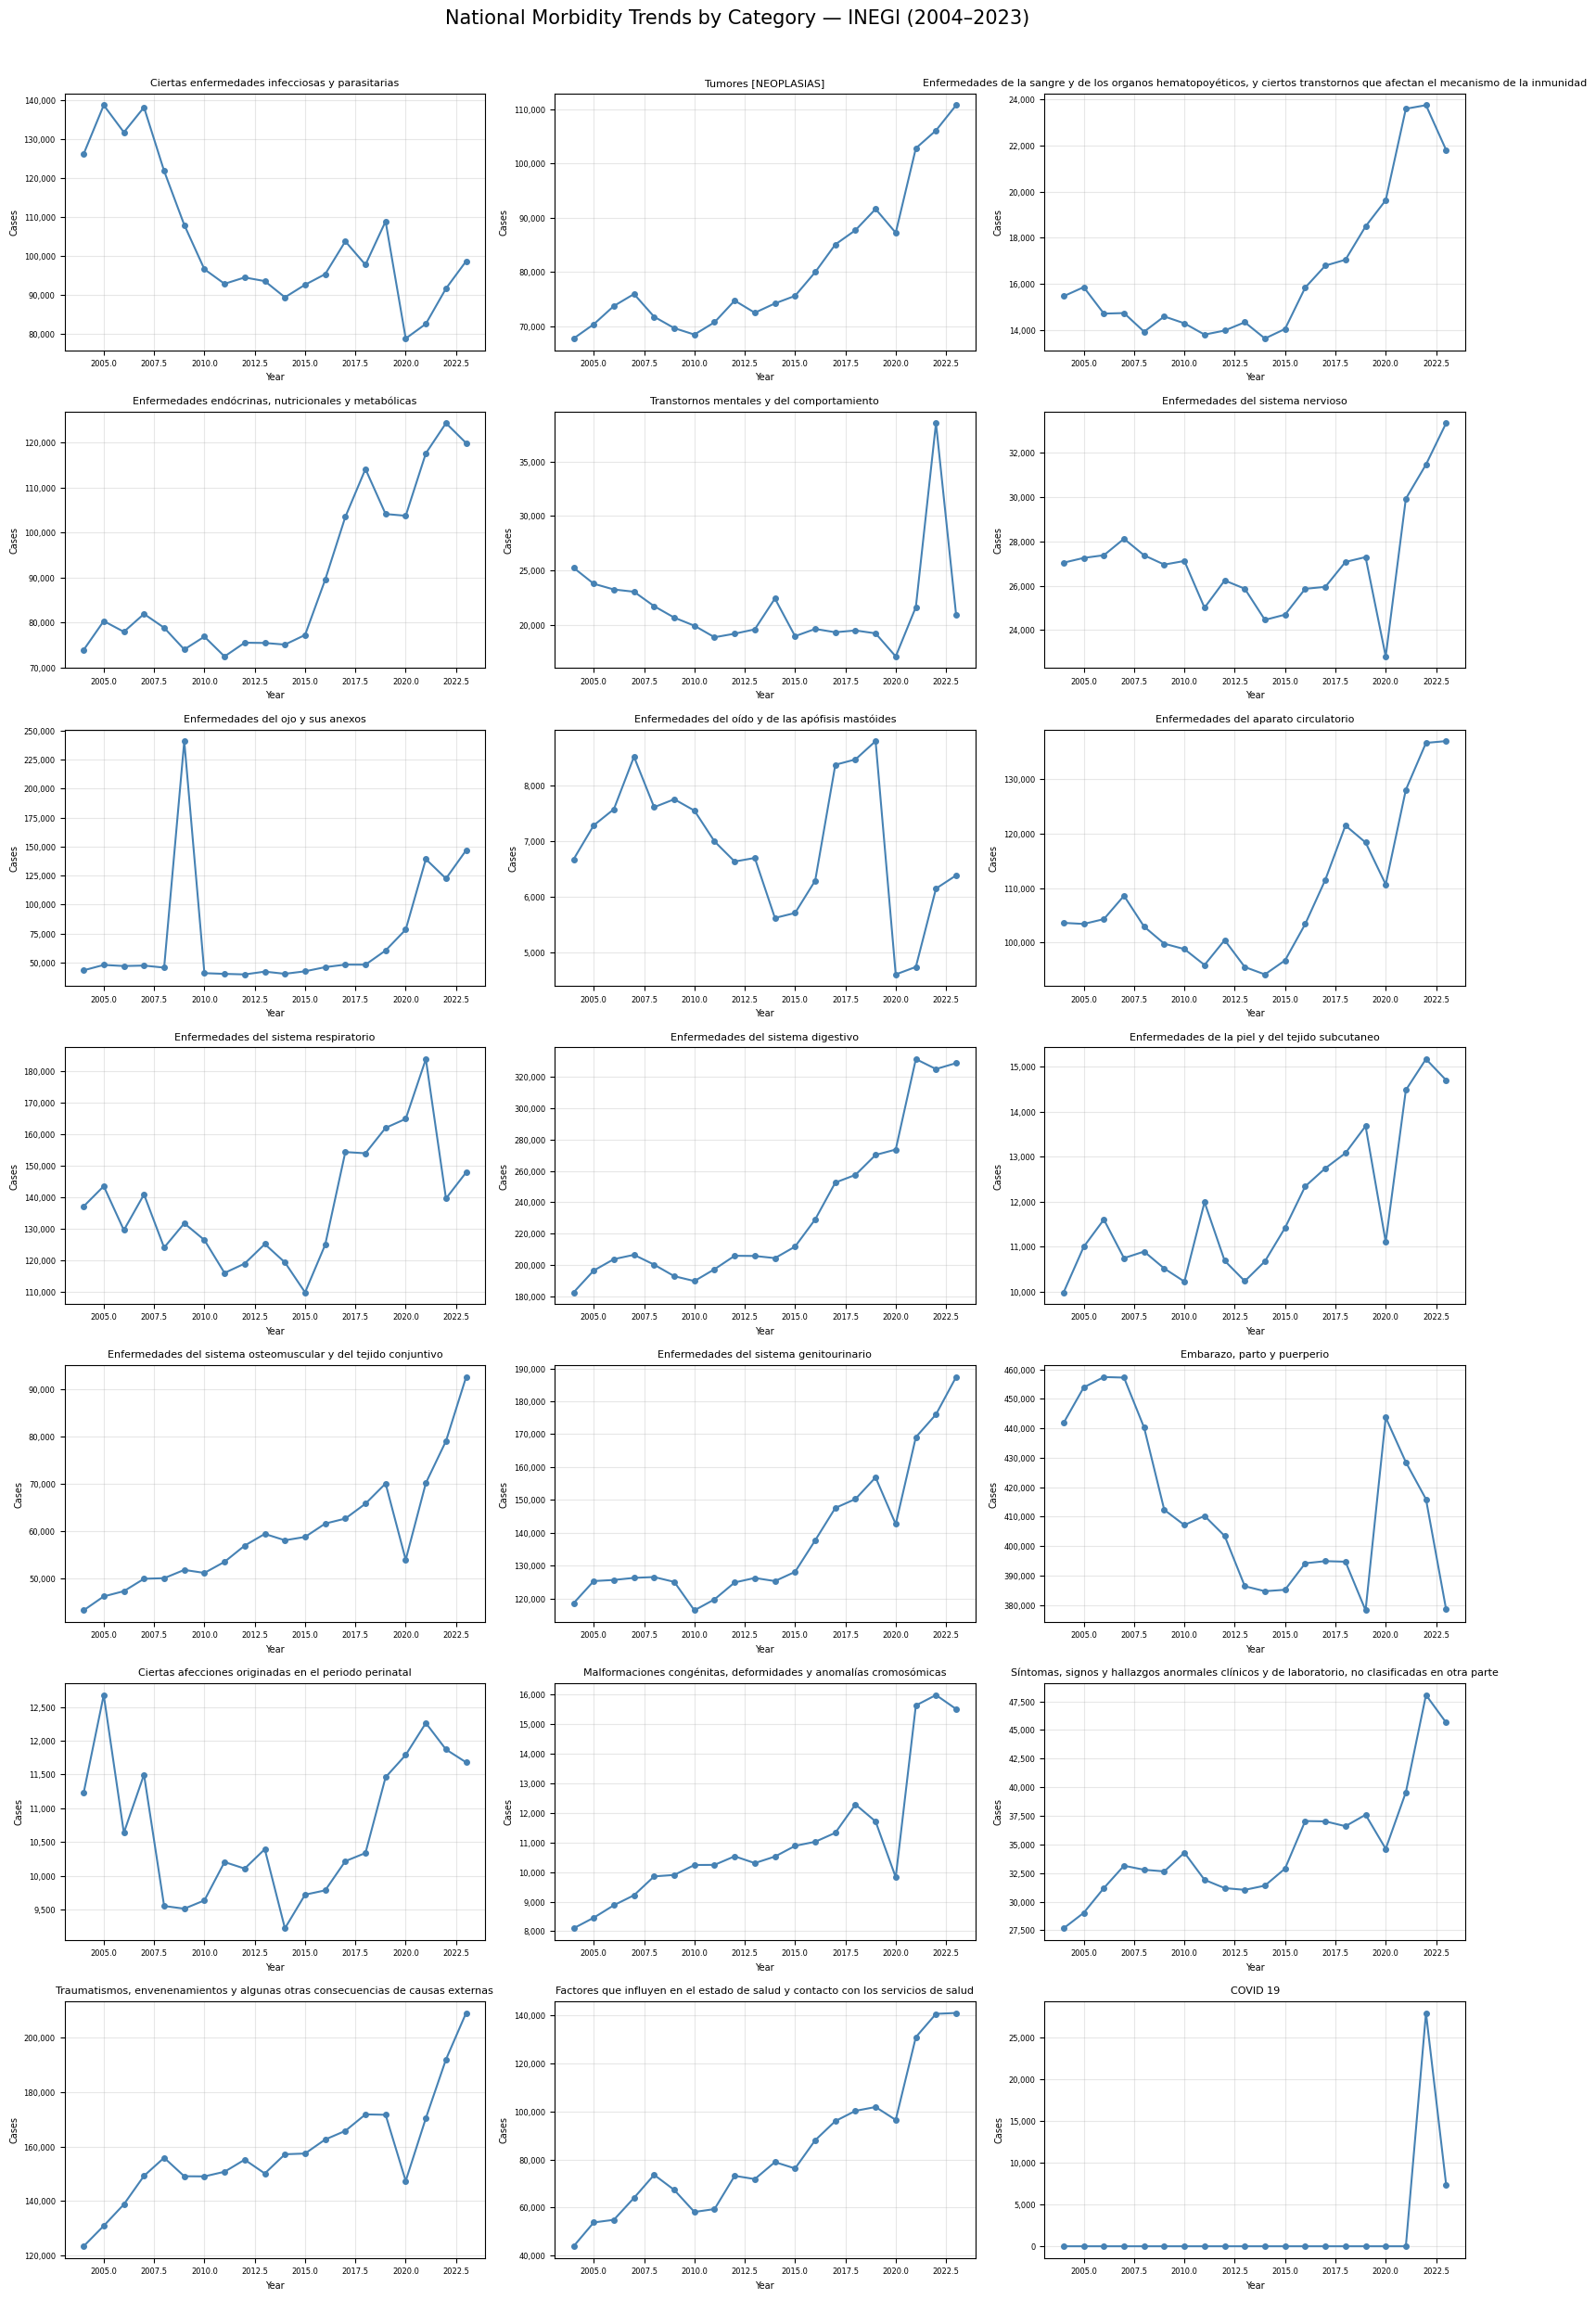

In [ ]:
n_cats = len(categories)
ncols  = 3
nrows  = (n_cats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
fig.suptitle('National Morbidity Trends by Category — INEGI (2004–2023)', fontsize=15, y=1.01)

for ax, cat in zip(axes.flat, categories):
    ax.plot(inegi['Año'], inegi[cat], marker='o', color='steelblue', markersize=4)
    ax.set_title(cat, fontsize=8)
    ax.set_xlabel('Year', fontsize=7)
    ax.set_ylabel('Cases', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_y))
    ax.grid(True, alpha=0.3)

# Hide any leftover empty axes
for ax in axes.flat[n_cats:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


**Findings — Morbidity Trends by Category (2004–2023):**

The following categories showed the most significant upward trends over the 20-year period:

- **Diseases of the digestive system** — sustained growth, reflecting dietary changes and aging population.
- **Diseases of the respiratory system** — consistent increase, amplified by urbanization and air quality issues.
- **Pregnancy, childbirth and puerperium** — steady growth aligned with population increase and expanded IMSS coverage.
- **Factors influencing health status and contact with health services** — strong upward trend, likely driven by greater system utilization and preventive care awareness.

Categories such as infectious and parasitic diseases showed more stable or declining trends, consistent with improved sanitation and vaccination coverage.


### 2.3 Predictive Modeling — Forecasting to 2030

Three models are trained per disease category. The one with the lowest MSE on the test set is selected as the best model for that category.

| Model | Notes |
|---|---|
| **Linear Regression** | Simple trend baseline |
| **Decision Tree** | Captures non-linearity; can overfit on short time series |
| **SVR (RBF kernel)** | Requires normalization; generally robust on small datasets |

An 80/20 train-test split is used. SVR data is scaled with `StandardScaler` before fitting and inverse-transformed for predictions.


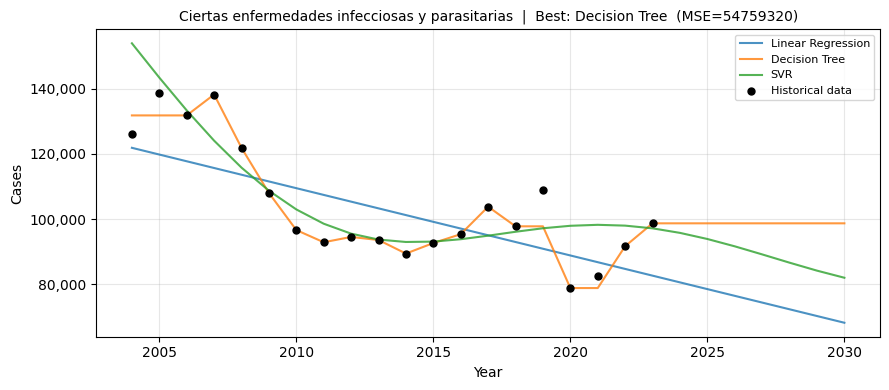

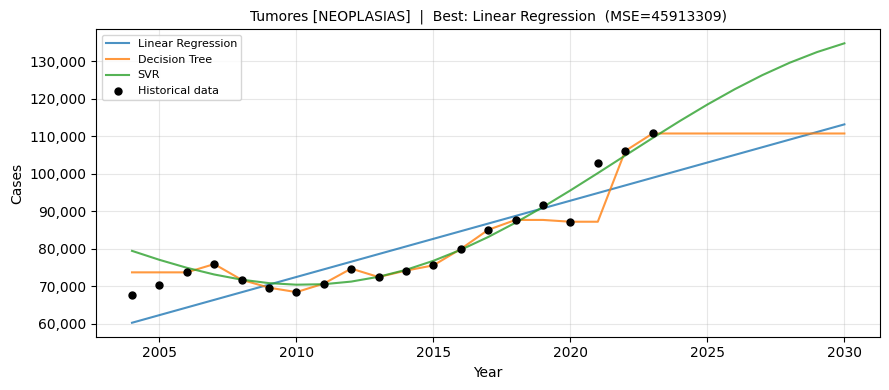

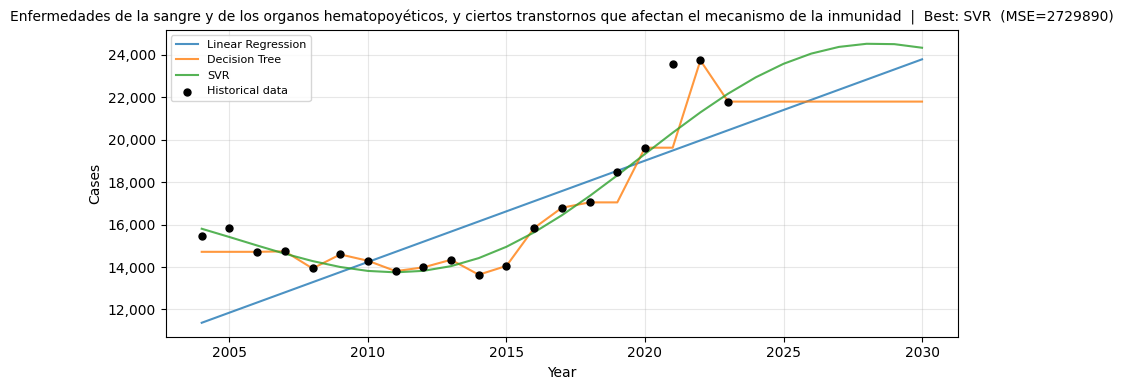

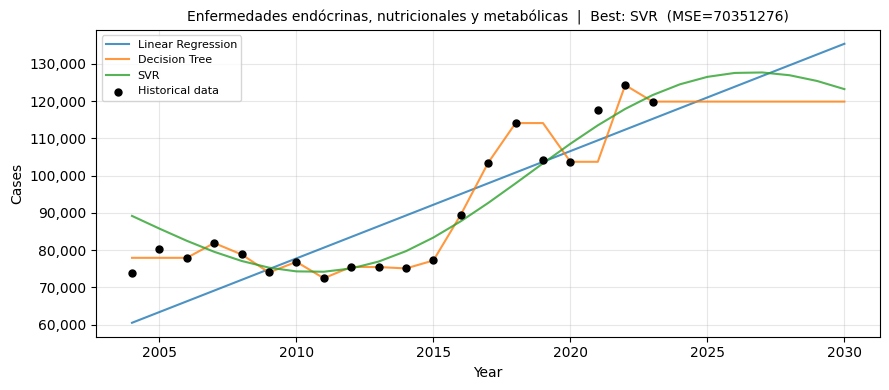

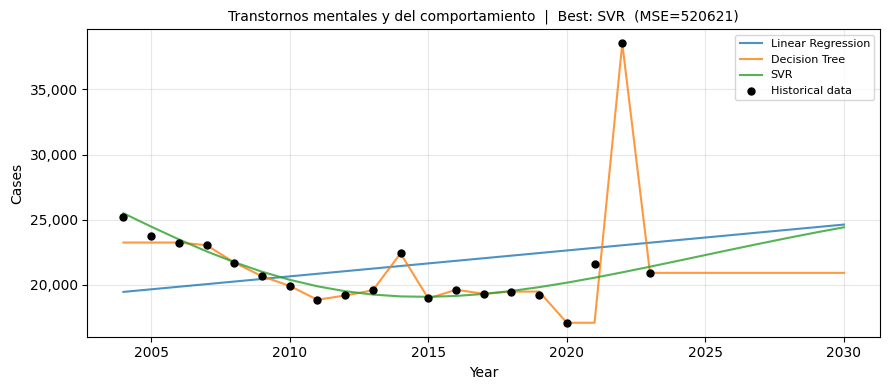

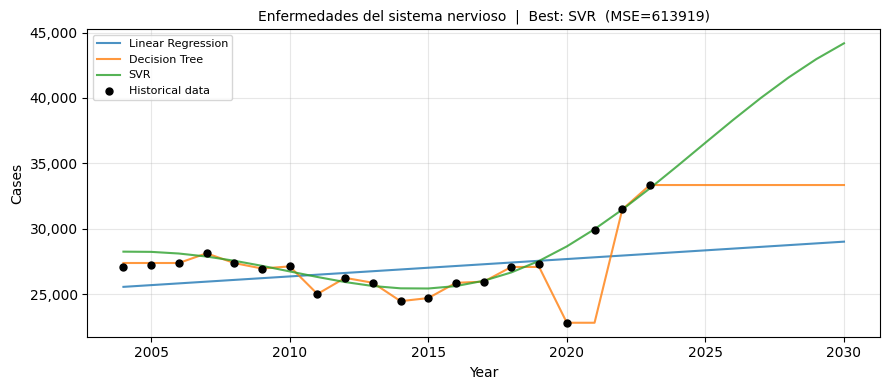

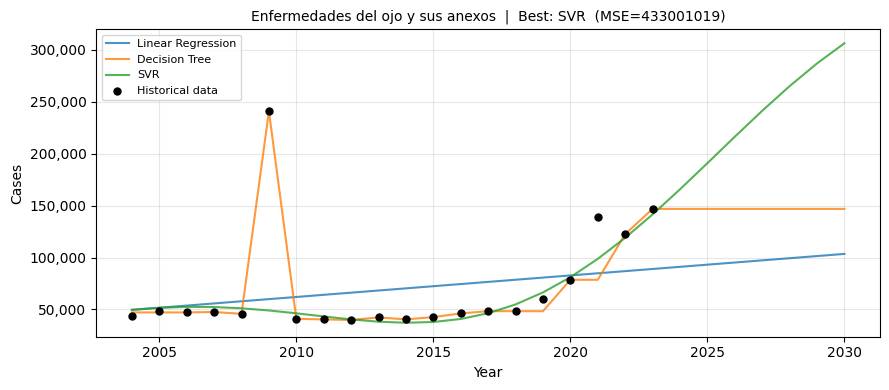

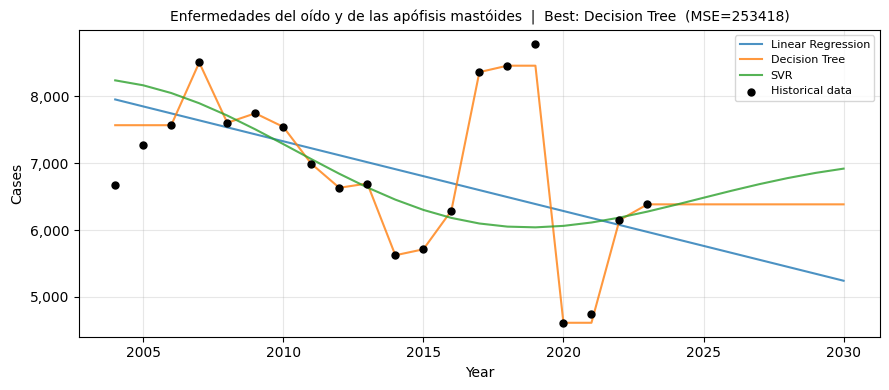

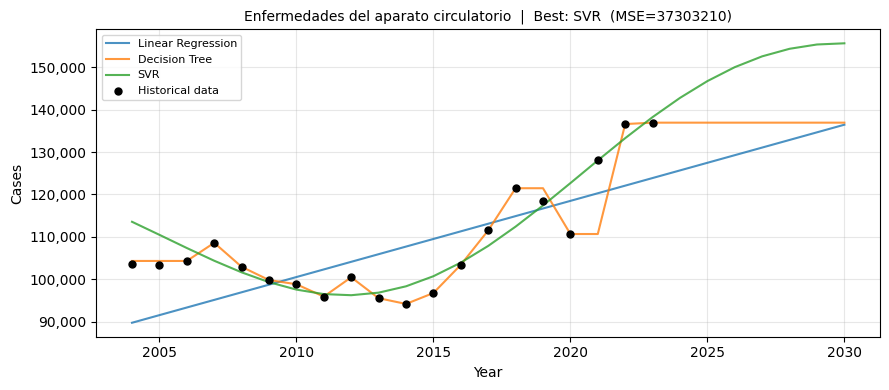

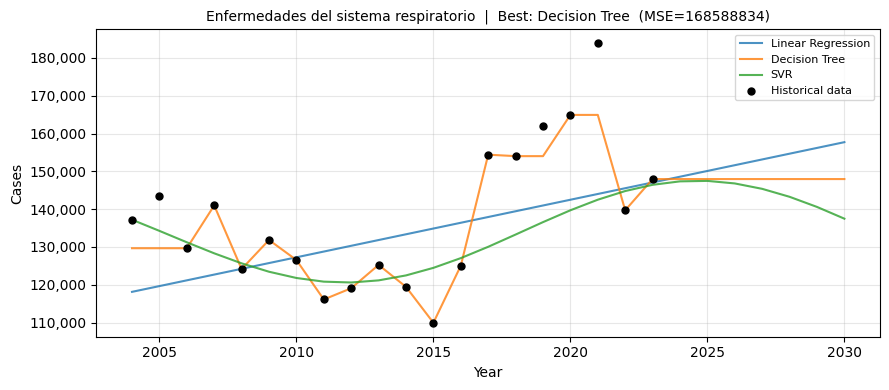

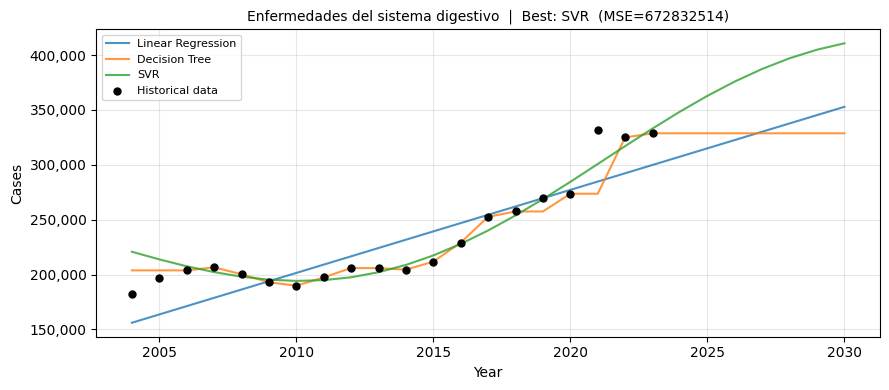

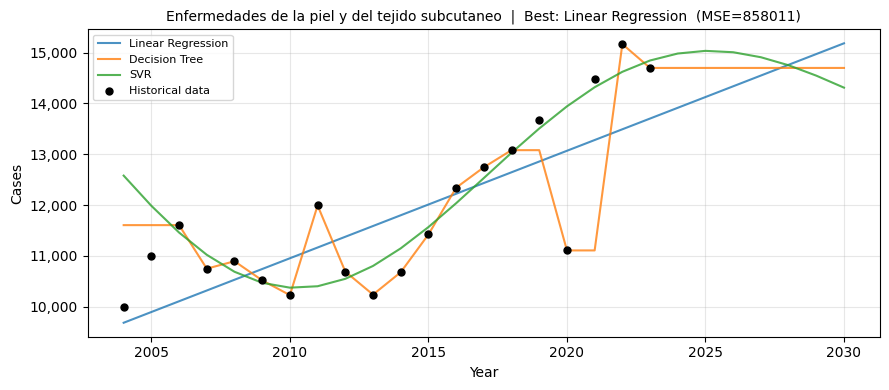

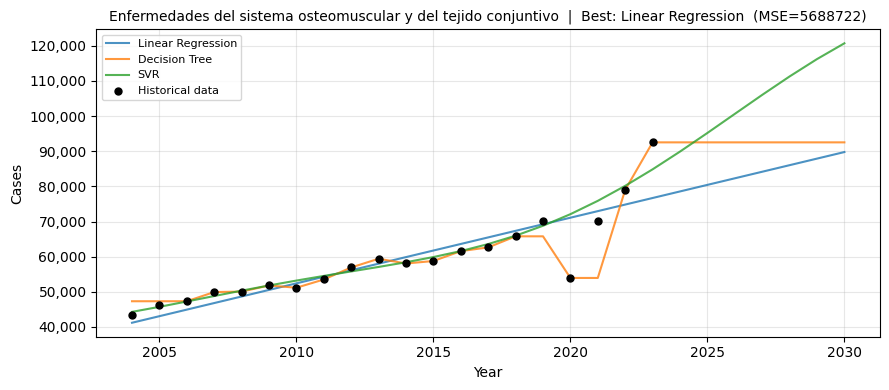

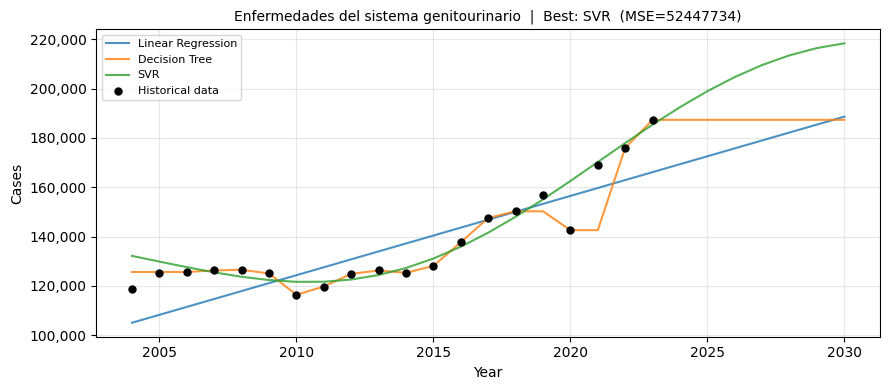

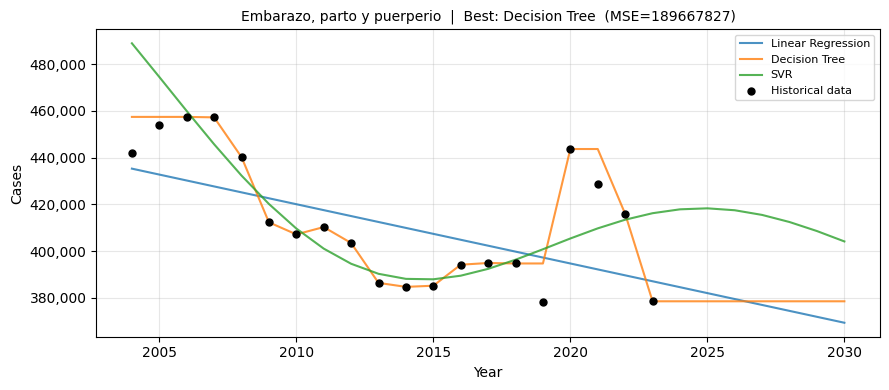

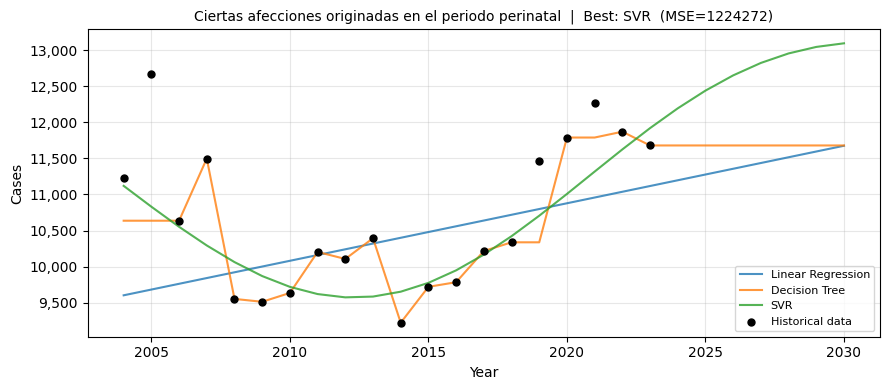

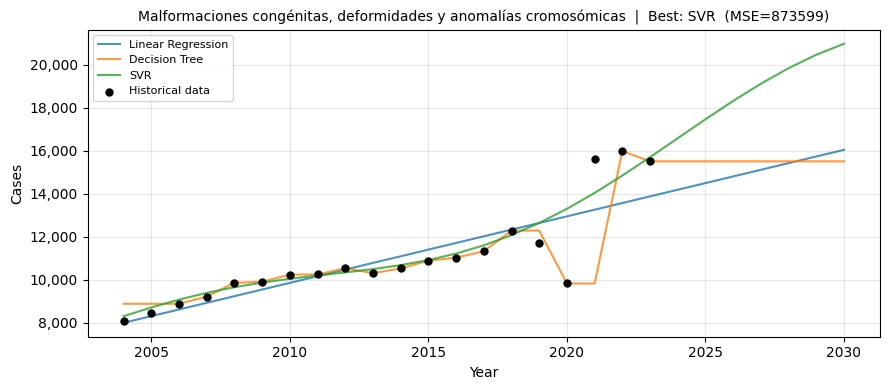

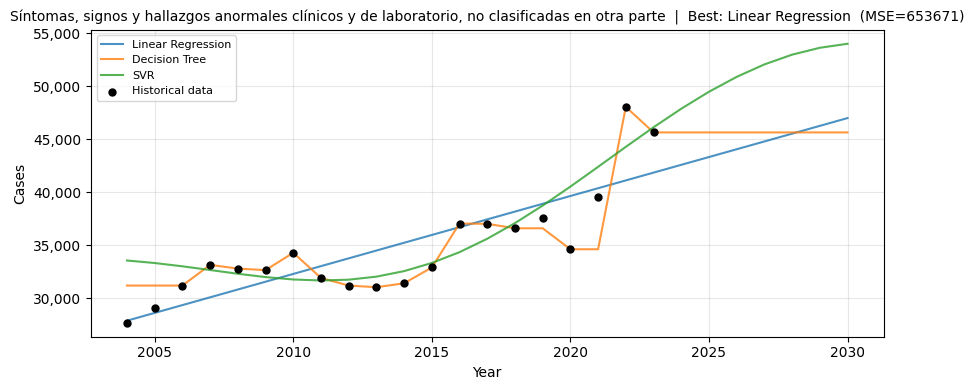

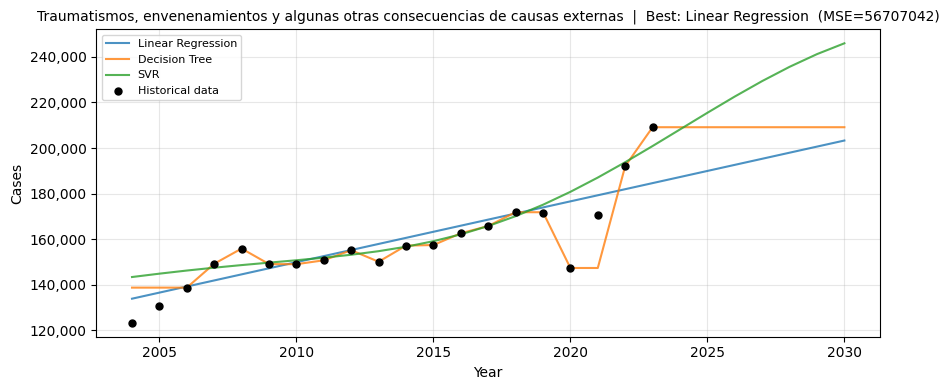

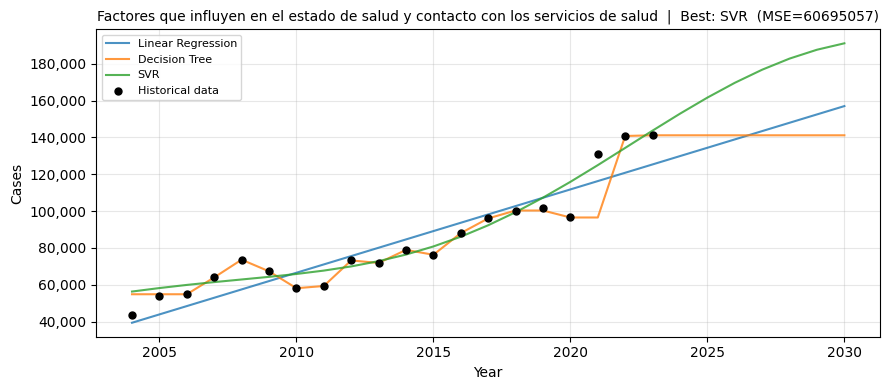

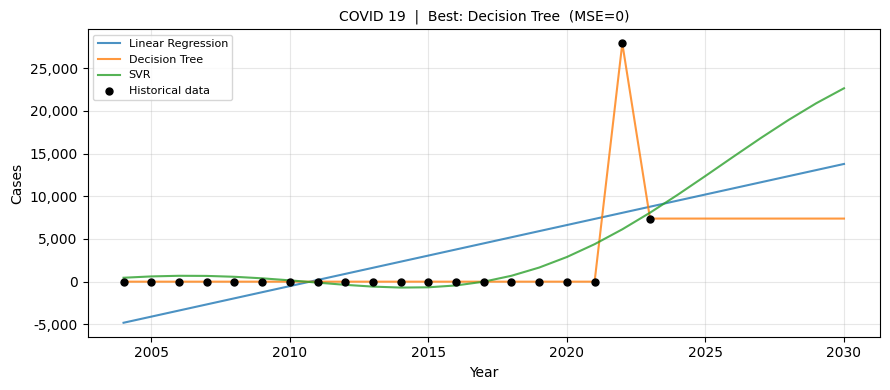


Best model per category:
                                                                                                                  Category        Best Model          MSE
                                                                           Ciertas enfermedades infecciosas y parasitarias     Decision Tree  54759319.75
                                                                                                      Tumores [NEOPLASIAS] Linear Regression  45913308.53
Enfermedades de la sangre y de los organos hematopoyéticos, y ciertos transtornos que afectan el mecanismo de la inmunidad               SVR   2729890.39
                                                                      Enfermedades endócrinas, nutricionales y metabólicas               SVR  70351275.53
                                                                                 Transtornos mentales y del comportamiento               SVR    520620.83
                                                  

In [ ]:
X      = inegi[['Año']].values
future = np.arange(int(inegi['Año'].min()), 2031).reshape(-1, 1)

models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree'     : DecisionTreeRegressor(random_state=42),
    'SVR'               : SVR(kernel='rbf', C=100, gamma=0.1),
}

best_model_summary = []
best_predictions   = pd.DataFrame({'Año': future.flatten()})

for cat in categories:
    y = inegi[cat].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Scaling (used by all models; SVR needs it, others are unaffected by it here)
    sx, sy = StandardScaler(), StandardScaler()
    Xtr_s  = sx.fit_transform(X_train)
    ytr_s  = sy.fit_transform(y_train.reshape(-1,1)).ravel()
    Xte_s  = sx.transform(X_test)
    Xf_s   = sx.transform(future)

    mse_scores, preds_future = {}, {}

    for name, m in models.items():
        if name == 'SVR':
            m.fit(Xtr_s, ytr_s)
            y_hat   = sy.inverse_transform(m.predict(Xte_s).reshape(-1,1)).ravel()
            fut_hat = sy.inverse_transform(m.predict(Xf_s).reshape(-1,1)).ravel()
        else:
            m.fit(X_train, y_train)
            y_hat   = m.predict(X_test)
            fut_hat = m.predict(future)
        mse_scores[name]  = mean_squared_error(y_test, y_hat)
        preds_future[name] = fut_hat

    best_name = min(mse_scores, key=mse_scores.get)
    best_model_summary.append({'Category': cat, 'Best Model': best_name, 'MSE': round(mse_scores[best_name], 2)})
    best_predictions[cat] = preds_future[best_name]

    # Plot
    fig, ax = plt.subplots(figsize=(9, 4))
    for name, fp in preds_future.items():
        ax.plot(future, fp, label=name, alpha=0.8)
    ax.scatter(X, y, color='black', zorder=5, s=25, label='Historical data')
    ax.set_title(f'{cat}  |  Best: {best_name}  (MSE={mse_scores[best_name]:.0f})', fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel('Cases')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_y))
    plt.tight_layout()
    plt.show()

# Summary table
summary_df = pd.DataFrame(best_model_summary)
print("\nBest model per category:")
print(summary_df.to_string(index=False))


**Findings — Predictive Modeling:**

- **SVR** was the best-performing model for **8 out of 21 categories**, particularly for categories with non-linear or irregular trends.
- **Decision Tree** won for **7 categories**, capturing more complex patterns but showing overfitting tendencies on some short time series.
- **Linear Regression** was best for **6 categories** — typically those with clear, stable long-term trends.

**Projected demand increase by 2030:**
The growth is **not uniform across categories**. The projected ~25% increase in total patient volume is driven primarily by:
1. Diseases of the digestive system
2. Diseases of the respiratory system
3. Pregnancy, childbirth and puerperium

Categories like infectious/parasitic diseases and vaccine-preventable conditions are projected to remain stable or decline. This asymmetry has direct implications for resource planning — investments should be concentrated in digestive, respiratory, and maternal health infrastructure.


### 2.4 Disease Category Clustering

We cluster the 21 disease categories by their patient volume trajectories using two methods:

- **K-Means (k=6)**: Hard partition; we visualize all trajectories colored by cluster.
- **Hierarchical (Agglomerative, Ward linkage)**: Produces a dendrogram revealing the nested structure of similarity.

Data is normalized with `StandardScaler` before clustering so that high-volume categories don't dominate distance calculations.


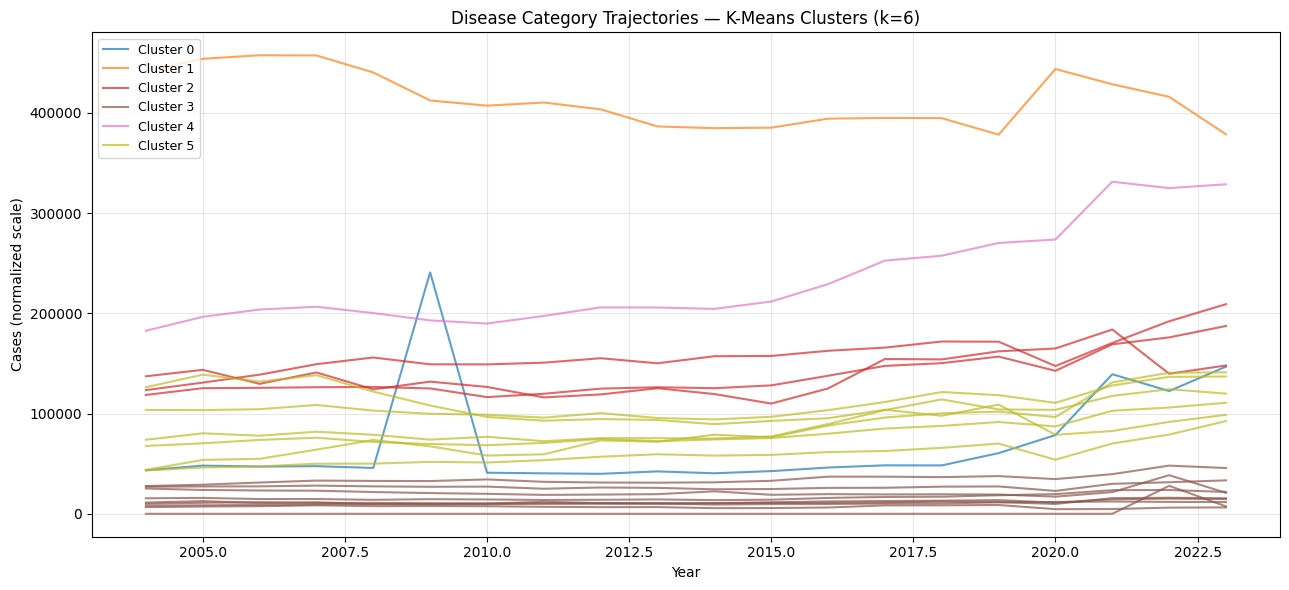

                                                                                                                  Category  K-Means Cluster
                                                                                         Enfermedades del ojo y sus anexos                0
                                                                                               Embarazo, parto y puerperio                1
                                                                                     Enfermedades del sistema respiratorio                2
                                                                                   Enfermedades del sistema genitourinario                2
                                            Traumatismos, envenenamientos y algunas otras consecuencias de causas externas                2
                                                                         Enfermedades del oído y de las apófisis mastóides                3
                    

In [ ]:
# Prepare matrix: rows = categories, columns = years
cat_matrix        = inegi[categories].T.copy()
cat_matrix.columns = inegi['Año'].values
cat_matrix         = cat_matrix.apply(pd.to_numeric, errors='coerce').fillna(0)

scaler = StandardScaler()
mat_s  = scaler.fit_transform(cat_matrix)

# ── K-Means ────────────────────────────────────────────────────────────────
n_clusters = 6
km  = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
km_labels = km.fit_predict(mat_s)

palette = plt.cm.tab10
fig, ax = plt.subplots(figsize=(13, 6))
for cluster in range(n_clusters):
    idx = np.where(km_labels == cluster)[0]
    for i in idx:
        label = f'Cluster {cluster}' if i == idx[0] else ''
        ax.plot(cat_matrix.columns, cat_matrix.iloc[i], color=palette(cluster/n_clusters),
                alpha=0.7, label=label)
ax.set_title('Disease Category Trajectories — K-Means Clusters (k=6)')
ax.set_xlabel('Year')
ax.set_ylabel('Cases (normalized scale)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cluster assignment table
km_df = pd.DataFrame({'Category': categories, 'K-Means Cluster': km_labels}).sort_values('K-Means Cluster')
print(km_df.to_string(index=False))


**Findings — K-Means Clustering (Disease Categories):**

The 6 clusters group disease categories by the shape and volume of their patient trajectories:

| Cluster group | Characteristics | Example categories |
|---|---|---|
| High-volume & growing (1, 2, 4) | Large absolute patient counts with upward trends | Digestive, Respiratory, Pregnancy/childbirth |
| Low-volume & stable (0, 3, 5) | Smaller absolute counts, flatter or variable trends | Tumors, Endocrine/metabolic, Infectious diseases |

This segmentation is actionable: conditions in the same cluster likely require similar resource types (beds, specialists, medications), enabling planners to group procurement and staffing decisions accordingly.


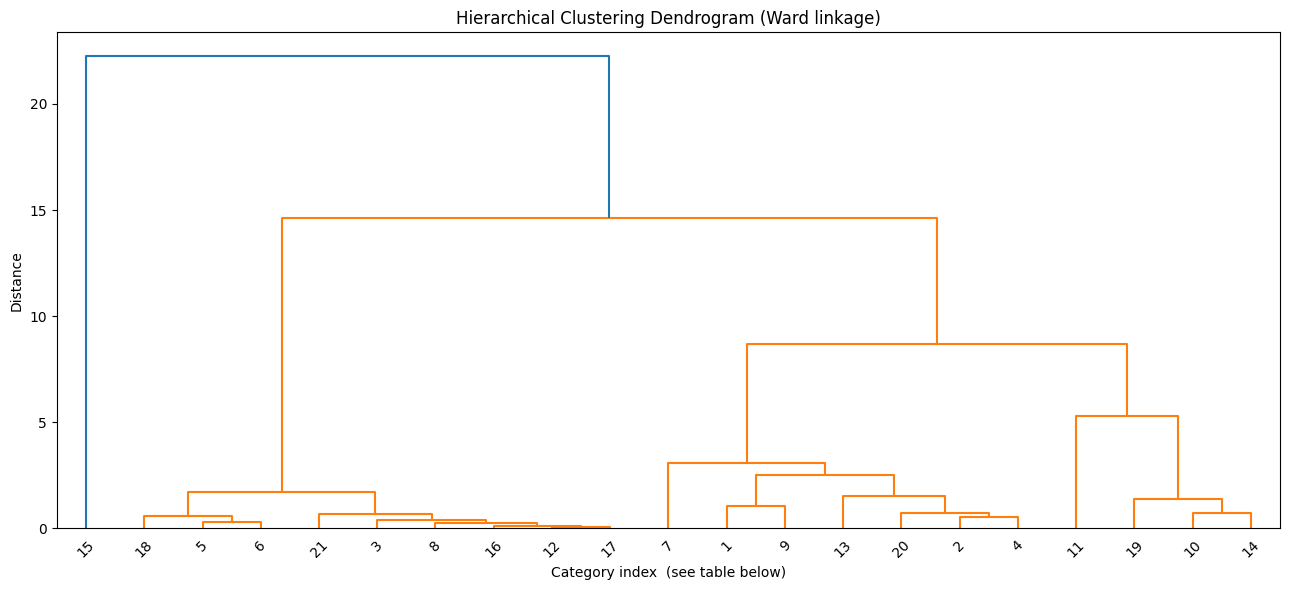

 Index                                                                                                                   Category
     1                                                                            Ciertas enfermedades infecciosas y parasitarias
     2                                                                                                       Tumores [NEOPLASIAS]
     3 Enfermedades de la sangre y de los organos hematopoyéticos, y ciertos transtornos que afectan el mecanismo de la inmunidad
     4                                                                       Enfermedades endócrinas, nutricionales y metabólicas
     5                                                                                  Transtornos mentales y del comportamiento
     6                                                                                          Enfermedades del sistema nervioso
     7                                                                                    

In [ ]:
# ── Hierarchical Clustering — Dendrogram ──────────────────────────────────
linkage_matrix = linkage(mat_s, method='ward')

plt.figure(figsize=(13, 6))
dendrogram(
    linkage_matrix,
    labels       = [str(i+1) for i in range(len(categories))],
    leaf_rotation= 45,
    leaf_font_size= 10,
)
plt.title('Hierarchical Clustering Dendrogram (Ward linkage)')
plt.xlabel('Category index  (see table below)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Index → category name reference
ref = pd.DataFrame({'Index': range(1, len(categories)+1), 'Category': categories})
print(ref.to_string(index=False))


**Findings — Hierarchical Clustering:**

The dendrogram confirms the K-Means groupings and adds a nested structure:

- At the highest level, diseases split into two broad super-clusters: **high-burden systemic conditions** (digestive, respiratory, maternal) vs. **lower-burden or specialized conditions** (neurological, sensory, rare diseases).
- The ward linkage method minimizes within-cluster variance, producing compact and interpretable groups.
- Categories that merge at low distances (short branches) are nearly interchangeable in terms of demand trajectory — a useful signal for integrated care planning.

> Together, K-Means and hierarchical clustering provide consistent, complementary segmentations that can guide IMSS resource allocation at both a strategic (national) and operational (regional) level.


---
## Conclusions & Recommendations

### Key Findings

| Finding | Detail |
|---|---|
| **Most prevalent conditions** | Digestive, respiratory diseases, and pregnancy/childbirth cases represent the largest share of IMSS patient volume |
| **2030 forecast** | Best-fit predictive models project a **~25% increase** in total national patient demand |
| **Chronic disease growth** | Diabetes, hypertension, and metabolic disorders show sustained upward trends in INEGI data |
| **Geographic concentration** | Estado de México, CDMX, and Jalisco account for the highest IMSS volumes, creating urban overload while rural areas remain underserved |
| **Clustering** | K-Means and hierarchical clustering identify 6 distinct disease groups by patient volume trajectory, enabling targeted resource planning |

### Recommendations

1. **Strengthen primary care** and preventive programs (vaccination, chronic disease screening) to reduce downstream demand for specialized services.
2. **Improve rural infrastructure** to reduce patient migration from underserved states to urban hospitals.
3. **Adopt predictive models operationally** to anticipate demand spikes and pre-position resources by region and disease cluster.
4. **Improve IMSS data quality and organization** — current data structure limits the ability to run real-time, evidence-based decisions at scale.

---
*Tecnológico de Monterrey CDMX — Academic consulting engagement sponsored by BBVA, 2024.*
